### t1  pretreatment

#### 拟合附件三数据

In [29]:
# 拟合附件三数据
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# 读取数据
data = pd.read_excel('附件3-弹性模量与压力.xlsx', sheet_name='Sheet1')

x = data['压力(MPa)']
y = data['弹性模量(MPa)']

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei']  # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号

In [30]:
# print(x)
# print(y)

In [31]:
# 多项式拟合
degree = 5
coeffs = np.polyfit(x, y, degree)
poly_func = np.poly1d(coeffs)

# 计算R²
y_pred = poly_func(x)
ss_res = np.sum((y - y_pred) ** 2)
ss_tot = np.sum((y - np.mean(y)) ** 2)
r_squared = 1 - (ss_res / ss_tot)


#### print

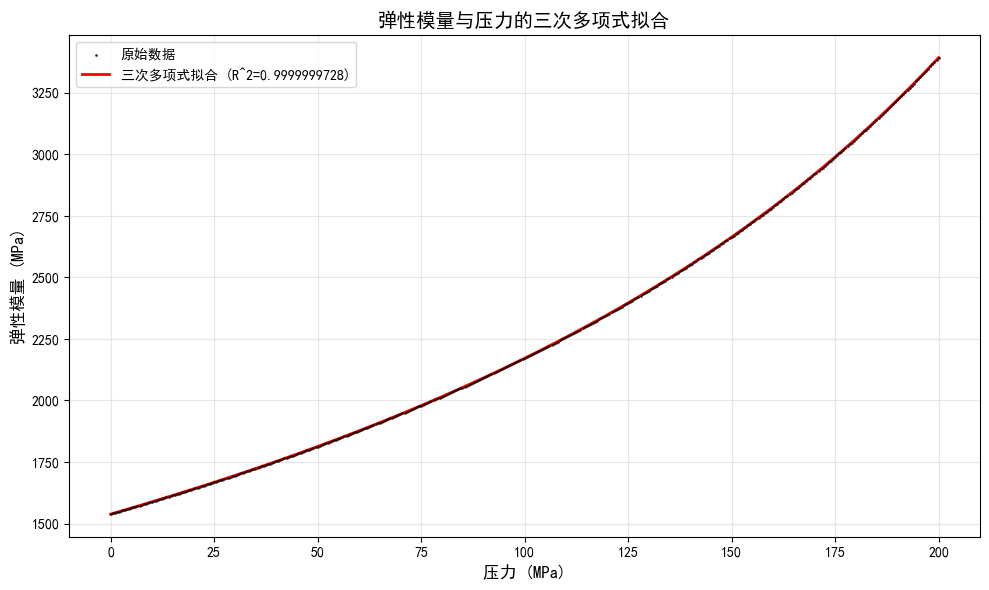

In [32]:
# 绘图
plt.figure(figsize=(10, 6))

# 绘制原始数据点
plt.scatter(x, y, color='black', s=1, alpha=0.7, label='原始数据', zorder=5)

# 生成平滑的拟合曲线
x_smooth = np.linspace(x.min(), x.max(), 300)
y_smooth = poly_func(x_smooth)

# 绘制拟合曲线
plt.plot(x_smooth, y_smooth, color='red', linewidth=2, 
         label=f'三次多项式拟合 (R^2={r_squared:.10f})')

plt.xlabel('压力 (MPa)', fontsize=12)
plt.ylabel('弹性模量 (MPa)', fontsize=12)
plt.title('弹性模量与压力的三次多项式拟合', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### 残差分析

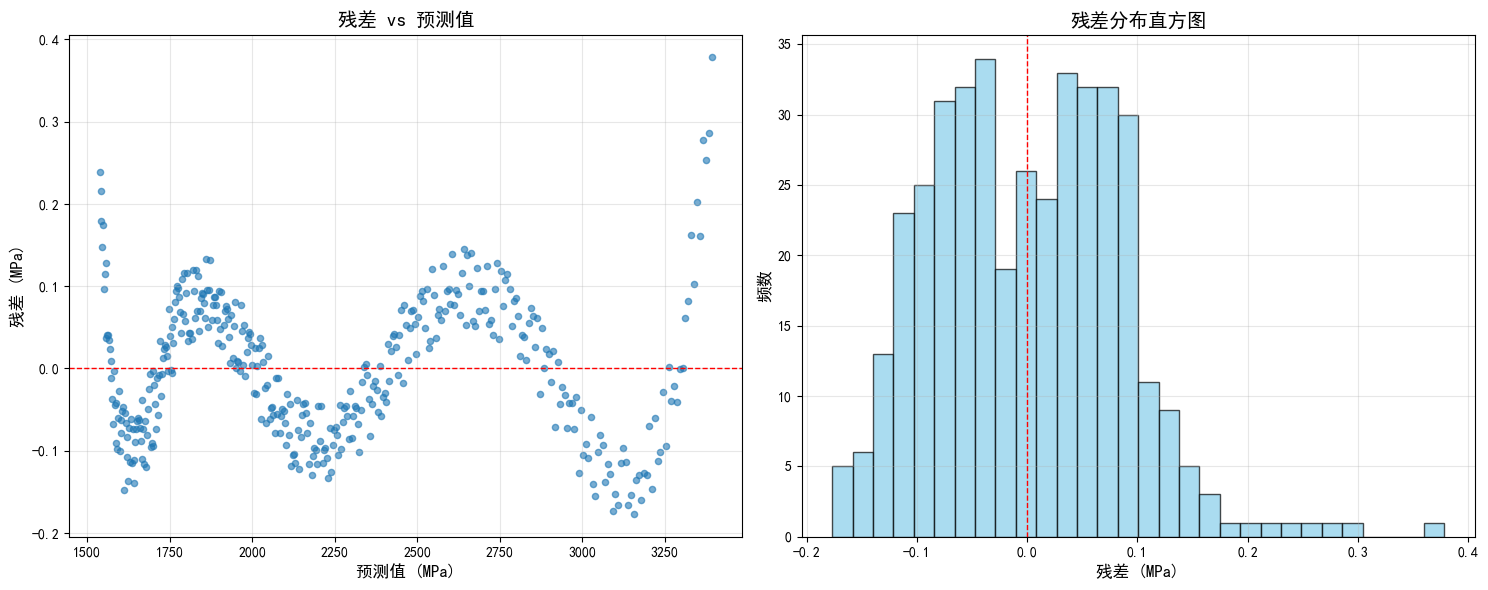


=== 残差分析 ===
残差均值: 0.000000 MPa
残差标准差: 0.085766 MPa
最大正残差: 0.378196 MPa
最大负残差: -0.176705 MPa
残差绝对值最大值: 0.378196 MPa


In [33]:
# 计算残差
residuals = y - y_pred

# 创建残差图
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# 残差 vs 预测值图
ax1.scatter(y_pred, residuals, alpha=0.6, s=20)
ax1.axhline(y=0, color='red', linestyle='--', linewidth=1)
ax1.set_xlabel('预测值 (MPa)', fontsize=12)
ax1.set_ylabel('残差 (MPa)', fontsize=12)
ax1.set_title('残差 vs 预测值', fontsize=14)
ax1.grid(True, alpha=0.3)

# 残差分布直方图
ax2.hist(residuals, bins=30, alpha=0.7, color='skyblue', edgecolor='black')
ax2.axvline(x=0, color='red', linestyle='--', linewidth=1)
ax2.set_xlabel('残差 (MPa)', fontsize=12)
ax2.set_ylabel('频数', fontsize=12)
ax2.set_title('残差分布直方图', fontsize=14)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 打印残差统计信息
print(f"\n=== 残差分析 ===")
print(f"残差均值: {np.mean(residuals):.6f} MPa")
print(f"残差标准差: {np.std(residuals):.6f} MPa")
print(f"最大正残差: {np.max(residuals):.6f} MPa")
print(f"最大负残差: {np.min(residuals):.6f} MPa")
print(f"残差绝对值最大值: {np.max(np.abs(residuals)):.6f} MPa")

#### func

In [34]:
# 打印拟合结果
print(f"\n{degree}次多项式拟合结果:")
print(f"R² = {r_squared:.6f}")
print(f"多项式系数: {coeffs}")

# 构建方程字符串
equation = "y = "
for j, coeff in enumerate(coeffs):
    power = degree - j
    if j == 0:
        if power == 1:
            equation += f"{coeff:.6e}*x"
        elif power == 0:
            equation += f"{coeff:.6e}"
        else:
            equation += f"{coeff:.6e}*x^{power}"
    else:
        if coeff >= 0:
            sign = " + "
        else:
            sign = " - "
            coeff = abs(coeff)
        
        if power == 1:
            equation += f"{sign}{coeff:.6e}*x"
        elif power == 0:
            equation += f"{sign}{coeff:.6e}"
        else:
            equation += f"{sign}{coeff:.6e}*x^{power}"

print(f"拟合方程: {equation}")


5次多项式拟合结果:
R² = 1.000000
多项式系数: [ 1.19866482e-09 -2.53914696e-07  6.83525578e-05  8.69584531e-03
  4.91448456e+00  1.53816139e+03]
拟合方程: y = 1.198665e-09*x^5 - 2.539147e-07*x^4 + 6.835256e-05*x^3 + 8.695845e-03*x^2 + 4.914485e+00*x + 1.538161e+03


#### E = func(P)

In [35]:
# 多项式预测功能
def E_func(pressure):
    """
    根据压力预测弹性模量（使用5次多项式）
    参数:
    pressure: 压力值(MPa)
    
    返回:
    弹性模量预测值(MPa)
    """
    return poly_func(pressure)

#### ρ(P)

In [36]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# 定义微分方程 d(rho)/dP = rho / E(P)
def drho_dP(P, rho):
    return rho / E_func(P)

# 3. 设置初始条件
P0 = 100      # 初始压力 (MPa)
rho0 = 0.850  # 初始密度 (mg/mm^3)

# 4. 设置求解的压力范围 (例如 0.01 到 200 MPa)
P_min = 0
P_max = 200

In [37]:
# --- 第一部分：向前积分 (从 100 到 200) ---
P_span_fwd = (P0, P_max)
P_eval_fwd = np.linspace(P_span_fwd[0], P_span_fwd[1], 10000001)
sol_fwd = solve_ivp(
    fun=drho_dP,
    t_span=P_span_fwd,
    y0=[rho0],
    t_eval=P_eval_fwd,
    method='RK45'
)

# --- 第二部分：向后积分 (从 100 到 0.01) ---
# 只需要将积分区间反向即可
P_span_bwd = (P0, P_min)
P_eval_bwd = np.linspace(P_span_bwd[0], P_span_bwd[1], 10000001)
sol_bwd = solve_ivp(
    fun=drho_dP,
    t_span=P_span_bwd,
    y0=[rho0],
    t_eval=P_eval_bwd,
    method='RK45'
)

In [38]:
# 5. 合并和整理结果
# 向后积分的结果是 P 值递减的，我们需要将其翻转过来
P_bwd_sorted = np.flip(sol_bwd.t)
rho_bwd_sorted = np.flip(sol_bwd.y[0])

# 将两部分结果拼接在一起
# 注意：P=100 的点会在两部分结果中都出现，所以我们去掉一个
P_values = np.concatenate((P_bwd_sorted[:-1], sol_fwd.t))
rho_values = np.concatenate((rho_bwd_sorted[:-1], sol_fwd.y[0]))

#### print 

在 P=160.000000 MPa 时, 密度为 0.871122 mg/mm³


d:\Anaconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 179 (\N{SUPERSCRIPT THREE}) missing from font(s) SimHei.
  fig.canvas.print_figure(bytes_io, **kw)
d:\Anaconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


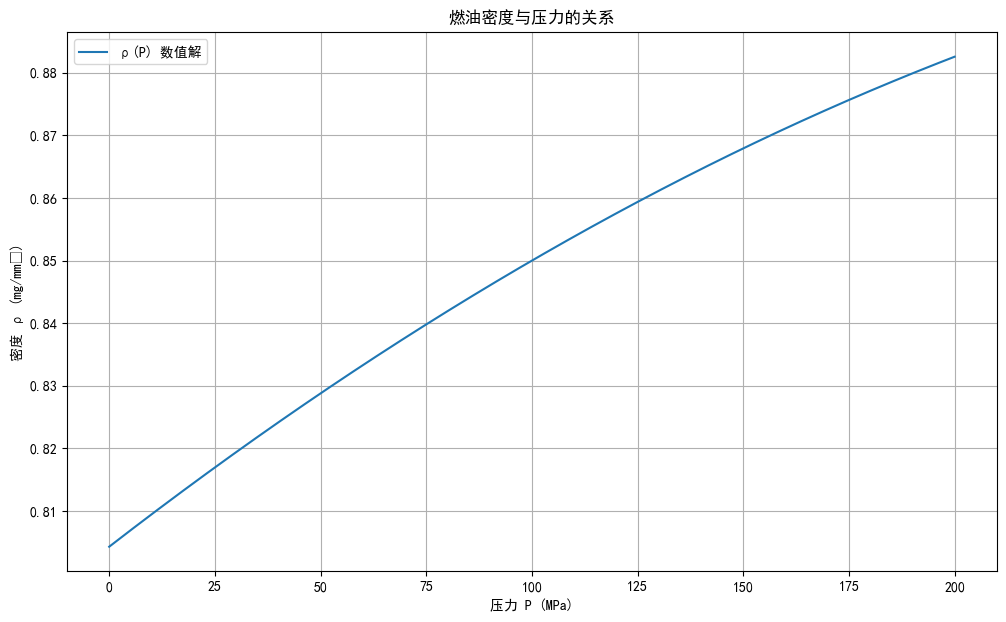

In [39]:
# 6. 验证和可视化
print(f"在 P={P_values[np.where(P_values == 160)[0][0]]:.6f} MPa 时, 密度为 {rho_values[np.where(P_values == 160)[0][0]]:.6f} mg/mm³")
plt.figure(figsize=(12, 7))
plt.plot(P_values, rho_values, label='ρ(P) 数值解')
plt.xlabel("压力 P (MPa)")
plt.ylabel("密度 ρ (mg/mm³)")
plt.title("燃油密度与压力的关系")
plt.grid(True)
plt.legend()
plt.show()

#### ρ(P) function

In [40]:
P_start = P_values[0]
P_stop = P_values[-1]
P_num_points = len(P_values)

# 预先计算步长
step = (P_stop - P_start) / (P_num_points - 1)

def rho(P):
    index = int(round((P - P_start) / step))
    return rho_values[index]


In [41]:
import math
# rho(0.5)
0.804548648196197 * math.pi * 2.5 * 2.5 * 5.845

92.3350768547823

### t1_1 iter calculate

In [26]:
from scipy.optimize import brentq
import math

# --- 1. 物理参数和常数定义 ---
L = 500  # 高压油管长度 (mm)
d = 10   # 高压油管内径 (mm)
V_pipe = math.pi * (d / 2)**2 * L  # 高压油管体积 (mm^3)

d_A = 1.4  # A口小孔直径 (mm)
A_A = math.pi * (d_A / 2)**2  # A口小孔面积 (mm^2)
C = 0.85   # 流量系数
P_pump = 160  # A口供油压力 (MPa)

P_initial = 150  # 油管初始压力 (MPa)
t_A_close = 10   # A口关闭时间 (ms)
T_total =30000     # 工作总时间 (ms)
T_B = 100  # B口工作周期 (ms)
dt = 0.01        # 时间步长 (ms)
N_steps = int(T_total / dt)
time_grid = np.linspace(0, T_total, N_steps + 1)

n = 0.5
T_total_valid = int(n * T_total)
N_steps_valid = int(n * N_steps)
time_grid_valid = np.linspace(0, T_total_valid, N_steps_valid + 1)

# --- 3. B喷嘴的喷油速率 Q_B(t) ---
def get_Q_B(t):
    """根据图2，返回t时刻B口的喷油速率"""
    t = t % T_B

    if 0 <= t < 0.2:
        return 100 * t
    elif 0.2 <= t < 2.2:
        return 20
    elif 2.2 <= t < 2.4:
        return 20 - 100 * (t - 2.2)
    else:
        return 0

rho_160 = rho(P_pump)  

In [27]:
# --- 4. 建立压力模拟函数 ---
# 预先计算160MPa下的密度，因为它在循环中是常量
def simulate_pressure(t_A):
    """
    模拟一段时间内的压力变化。
    参数 t_A: A阀门的开启时长 (ms)
    返回: 目标函数
    """
    P = np.zeros(N_steps + 1)
    P[0] = P_initial
    res = 0

    for i in range(N_steps):
        t_current = time_grid[i]
        P_current = P[i]

        # 防止压力计算超出我们预设的插值范围
        if not (0 <= P_current <= 200):
            return -1e15 # 返回一个很大的误差值，引导优化器避开此区域

        # 计算A口的瞬时流量 Q_A
        is_A_open = 1 if (t_current % (t_A + t_A_close)) < t_A else 0
        delta_P_A = P_pump - P_current
        
        if delta_P_A > 0: #Q_A
            Q_A = is_A_open * C * A_A * math.sqrt(2 * delta_P_A / rho_160)
        else:
            Q_A = 0

        # B口的瞬时流量 Q_B
        Q_B = get_Q_B(t_current)

        # 获取当前压力下的物性参数
        rho_current = rho(round(P_current, 6)) # 使传入的P四舍五入到6位小数

        E_current = E_func(P_current)
        
        # 根据质量守恒计算净质量流速
        mass_flow_in = rho_160 * Q_A
        mass_flow_out = rho_current * Q_B
        dM_dt = mass_flow_in - mass_flow_out
        
        # 根据物理关系 dP/dt = (E/rho/V) * dM/dt 计算压力变化率
        dP_dt = (E_current / (rho_current * V_pipe)) * dM_dt
        
        # 使用欧拉法更新下一时刻的压力
        P[i+1] = P_current + dP_dt * dt

        #if t_current % 1 == 0:
        res += (P_current - P_initial)**2

    return res / (N_steps+1)#T_total #

def simulate_pressure_valid(t_A):
    P = np.zeros(N_steps_valid + 1)
    P[0] = P_initial

    for i in range(N_steps_valid):
        t_current = time_grid_valid[i]
        P_current = P[i]

        # 计算A口的瞬时流量 Q_A
        is_A_open = 1 if (t_current % (t_A + t_A_close)) < t_A else 0
        delta_P_A = P_pump - P_current
        
        if delta_P_A > 0: #Q_A
            Q_A = is_A_open * C * A_A * math.sqrt(2 * delta_P_A / rho_160)
        else:
            Q_A = 0

        # B口的瞬时流量 Q_B
        Q_B = get_Q_B(t_current)

        # 获取当前压力下的物性参数
        rho_current = rho(round(P_current, 6)) # 使传入的P四舍五入到6位小数

        E_current = E_func(P_current)
        
        # 根据质量守恒计算净质量流速
        mass_flow_in = rho_160 * Q_A
        mass_flow_out = rho_current * Q_B
        dM_dt = mass_flow_in - mass_flow_out
        
        # 根据物理关系 dP/dt = (E/rho/V) * dM/dt 计算压力变化率
        dP_dt = (E_current / (rho_current * V_pipe)) * dM_dt
        
        # 使用欧拉法更新下一时刻的压力
        P[i+1] = P_current + dP_dt * dt

    return P

In [ ]:
# 我们需要先提供一个包含根的区间 [a, b]
# 通过测试两个点来确定这个区间
t_A_start = 0.7
t_A_stop = 0.8

val_at_0_1 = simulate_pressure(t_A_start)
val_at_0_4 = simulate_pressure(t_A_stop)

print(f"测试: 当 t_A={t_A_start}ms, 残差平方和: {val_at_0_1:.4f} MPa")
print(f"测试: 当 t_A={t_A_stop}ms,  残差平方和: {val_at_0_4:.4f} MPa")

In [ ]:
import time
from scipy.optimize import root_scalar, minimize_scalar

try:
    start_time = time.time()
    #sol = root_scalar(simulate_pressure, bracket=[t_A_start, t_A_stop], method='brentq') # root_scalar默认='brentq'
    ans = minimize_scalar(simulate_pressure, bounds=(t_A_start, t_A_stop), method='bounded', options={'xatol': 1e-8, 'maxiter': 40})

    end_time = time.time()
    if ans.success:
        print(f"求解成功！")
        print(f"找到的解为: {ans.x:.14f} ms")
        print(f"函数求值次数: {ans.nfev}")
        print(f"计算耗时: {(end_time - start_time)*1000:.1f} ms\n")
        val = simulate_pressure(ans.x)
        print(ans.fun)
        print(f"验证: 当 t_A={ans.x:.14f}ms, 目标函数为: {val:.14f} MPa")
    else:
        print("求解失败 (方法: brentq)。")

except Exception as e:
    print(f"\n发生错误: {e}\n")

求解成功！
找到的解为: 0.75283750019125 ms
函数求值次数: 24
计算耗时: 702837.9 ms

0.7378738986314041
验证: 当 t_A=0.75283750019125ms, 目标函数为: 0.73787389863140 MPa


In [ ]:
P = simulate_pressure_valid(ans.x)

In [ ]:
plt.figure(figsize=(20, 6))
plt.plot(time_grid_valid, P)
plt.xlabel('时间 (ms)')
plt.ylabel('压力 (MPa)')
plt.title('压力随时间变化')
plt.grid(True)
plt.show()

[100.         100.00870321 100.01685305 ... 101.32799142 101.3366363
 101.3452808 ]


### t1_2

In [91]:
# --- 1. 物理参数和常数定义 ---
L = 500  # 高压油管长度 (mm)
d = 10   # 高压油管内径 (mm)
V_pipe = math.pi * (d / 2)**2 * L  # 高压油管体积 (mm^3)

d_A = 1.4  # A口小孔直径 (mm)
A_A = math.pi * (d_A / 2)**2  # A口小孔面积 (mm^2)
C = 0.85   # 流量系数
P_pump = 160  # A口供油压力 (MPa)

P_initial = 100  # 油管初始压力 (MPa)
t_A_close = 10   # A口关闭时间 (ms)
T_total = 20000     # 工作周期 (ms)

P_target = 150  # 目标压力 (MPa)   
T_target = 10000    # 目标时限 (ms)  #------------------------------------------------------------------------------------------

T_B = 100  # B口工作周期 (ms)
dt = 0.01        # 时间步长 (ms)
N_steps = int(T_total / dt)
time_grid = np.linspace(0, T_total, N_steps + 1)

n = 1
T_total_valid = int(n * T_total)
N_steps_valid = int(n * N_steps)
time_grid_valid = np.linspace(0, T_total_valid, N_steps_valid + 1)

# --- 3. B喷嘴的喷油速率 Q_B(t) ---
def get_Q_B(t):
    """根据图2，返回t时刻B口的喷油速率"""
    t = t % T_B

    if 0 <= t < 0.2:
        return 100 * t
    elif 0.2 <= t < 2.2:
        return 20
    elif 2.2 <= t < 2.4:
        return 20 - 100 * (t - 2.2)
    else:
        return 0

rho_160 = rho(P_pump)

In [92]:
# --- 4. 建立压力模拟函数 ---
# 预先计算160MPa下的密度，因为它在循环中是常量
def simulate_pressure(t_AA):
    """
    模拟一段时间内的压力变化。
    参数 t_A: A阀门的开启时长 (ms)
    返回: 目标函数
    """
    t_A1 = t_AA#0.92892947716501 ##0.91790374984841#0.75496740777664 #
    t_A2 = t_AA#0.75172196259740 #t_AA
    P = np.zeros(N_steps + 1)
    P[0] = P_initial
    res = 0

    for i in range(N_steps):
        t_current = time_grid[i]
        if(t_current < T_target): t_A = t_A1
        else: t_A = t_A2

        P_current = P[i]
        # 防止压力计算超出我们预设的插值范围
        if not (0 <= P_current <= 200):
            return 1e9 # 返回一个很大的误差值，引导优化器避开此区域

        # 计算A口的瞬时流量 Q_A
        is_A_open = 1 if (t_current % (t_A + t_A_close)) < t_A else 0
        delta_P_A = P_pump - P_current
        
        if delta_P_A > 0: #Q_A
            Q_A = is_A_open * C * A_A * math.sqrt(2 * delta_P_A / rho_160)
        else:
            Q_A = 0

        # B口的瞬时流量 Q_B
        Q_B = get_Q_B(t_current)

        # 获取当前压力下的物性参数
        rho_current = rho(round(P_current, 6)) # 使传入的P四舍五入到6位小数

        E_current = E_func(P_current)
        
        # 根据质量守恒计算净质量流速
        mass_flow_in = rho_160 * Q_A
        mass_flow_out = rho_current * Q_B
        dM_dt = mass_flow_in - mass_flow_out
        
        # 根据物理关系 dP/dt = (E/rho/V) * dM/dt 计算压力变化率
        dP_dt = (E_current / (rho_current * V_pipe)) * dM_dt
        
        # 使用欧拉法更新下一时刻的压力
        P[i+1] = P_current + dP_dt * dt

        if t_current >= T_target:
            res += (P_current - P_target)**2

    return res / ((T_total - T_target) / dt + 1)

def simulate_pressure_valid(t_AA):
    t_A1 = t_AA#0.92892947716501 #t_AA #0.91790374984841 # #0.92525816385193
    t_A2 = t_AA#0.75172196259740 #t_AA
    P = np.zeros(N_steps_valid + 1)
    P[0] = P_initial

    for i in range(N_steps_valid):
        t_current = time_grid_valid[i]
        if(t_current < T_target): t_A = t_A1
        else: t_A = t_A2

        P_current = P[i]

        # 计算A口的瞬时流量 Q_A
        is_A_open = 1 if (t_current % (t_A + t_A_close)) < t_A else 0
        delta_P_A = P_pump - P_current
        
        if delta_P_A > 0: #Q_A
            Q_A = is_A_open * C * A_A * math.sqrt(2 * delta_P_A / rho_160)
        else:
            Q_A = 0

        # B口的瞬时流量 Q_B
        Q_B = get_Q_B(t_current)

        # 获取当前压力下的物性参数
        rho_current = rho(round(P_current, 6)) # 使传入的P四舍五入到6位小数

        E_current = E_func(P_current)
        
        # 根据质量守恒计算净质量流速
        mass_flow_in = rho_160 * Q_A
        mass_flow_out = rho_current * Q_B
        dM_dt = mass_flow_in - mass_flow_out
        
        # 根据物理关系 dP/dt = (E/rho/V) * dM/dt 计算压力变化率
        dP_dt = (E_current / (rho_current * V_pipe)) * dM_dt
        
        # 使用欧拉法更新下一时刻的压力
        P[i+1] = P_current + dP_dt * dt

    return P

In [153]:
# 我们需要先提供一个包含根的区间 [a, b]
# 通过测试两个点来确定这个区间
t_A_start = 0.28
t_A_stop = 2

val_at_0_1 = simulate_pressure(t_A_start)
print(f"测试: 当 t_A={t_A_start}ms, 目标函数: {val_at_0_1:.4f} MPa")

val_at_1 = simulate_pressure(t_A_stop)
print(f"测试: 当 t_A={t_A_stop}ms, 目标函数: {val_at_1:.4f} MPa")

测试: 当 t_A=0.28ms, 目标函数: 2800.2245 MPa
测试: 当 t_A=2ms, 目标函数: 66.6966 MPa


In [157]:
import time
from scipy.optimize import differential_evolution
# 假设 simulate_pressure, t_A_start, t_A_stop 已经定义好了
class ProgressTracker:
    def __init__(self):
        self.iteration = 0
        self.start_time = time.time()
    def __call__(self, xk, convergence):
        self.iteration += 1     
        print(f"Step {self.iteration:3d}: x = {xk}")# 打印格式化的进度
# 1. 创建一个包装函数，以适配 differential_evolution
def objective_function_wrapper(x):
    # differential_evolution 传入的是数组 x，我们取出第一个元素
    return simulate_pressure(x[0])

try:
    start_time = time.time()
    bounds = [(t_A_start, t_A_stop)]
    progress_tracker = ProgressTracker()

    # 使用包装函数和修正后的 bounds
    ans = differential_evolution(objective_function_wrapper, bounds=bounds, disp=True, callback=progress_tracker)

    end_time = time.time()

    if ans.success:
        print(f"求解成功！")
        print(f"找到的解为: {ans.x[0]:.14f} ms")
        print(f"目标函数最小值: {ans.fun:.14f}")
        print(f"函数求值次数: {ans.nfev}")
        print(f"计算耗时: {(end_time - start_time)*1000:.4f} ms\n")
    else:
        print("求解失败。")
        print(f"失败原因: {ans.message}")

except Exception as e:
    print(f"\n发生错误: {e}\n")

differential_evolution step 1: f(x)= 1.2420936492130634
Step   1: x = [0.78375498]
differential_evolution step 2: f(x)= 0.7206651896224715
Step   2: x = [0.75454457]
differential_evolution step 3: f(x)= 0.7206651896224715
Step   3: x = [0.75454457]
differential_evolution step 4: f(x)= 0.7206651896224715
Step   4: x = [0.75454457]
differential_evolution step 5: f(x)= 0.7206651896224715
Step   5: x = [0.75454457]
differential_evolution step 6: f(x)= 0.7199258969873766
Step   6: x = [0.7542201]
differential_evolution step 7: f(x)= 0.7177982019648054
Step   7: x = [0.75253731]
differential_evolution step 8: f(x)= 0.7177982019648054
Step   8: x = [0.75253731]
Polishing solution with 'L-BFGS-B'
求解成功！
找到的解为: 0.75253730848924 ms
目标函数最小值: 0.71779820196481
函数求值次数: 251
计算耗时: 5582367.1901 ms



In [110]:
P = simulate_pressure_valid(0.76402151850178)#0.75160779723083)#1)#
res = simulate_pressure(0.76402151850178)#0.75160779723083)

In [111]:
print(res)

0.7957266687194237


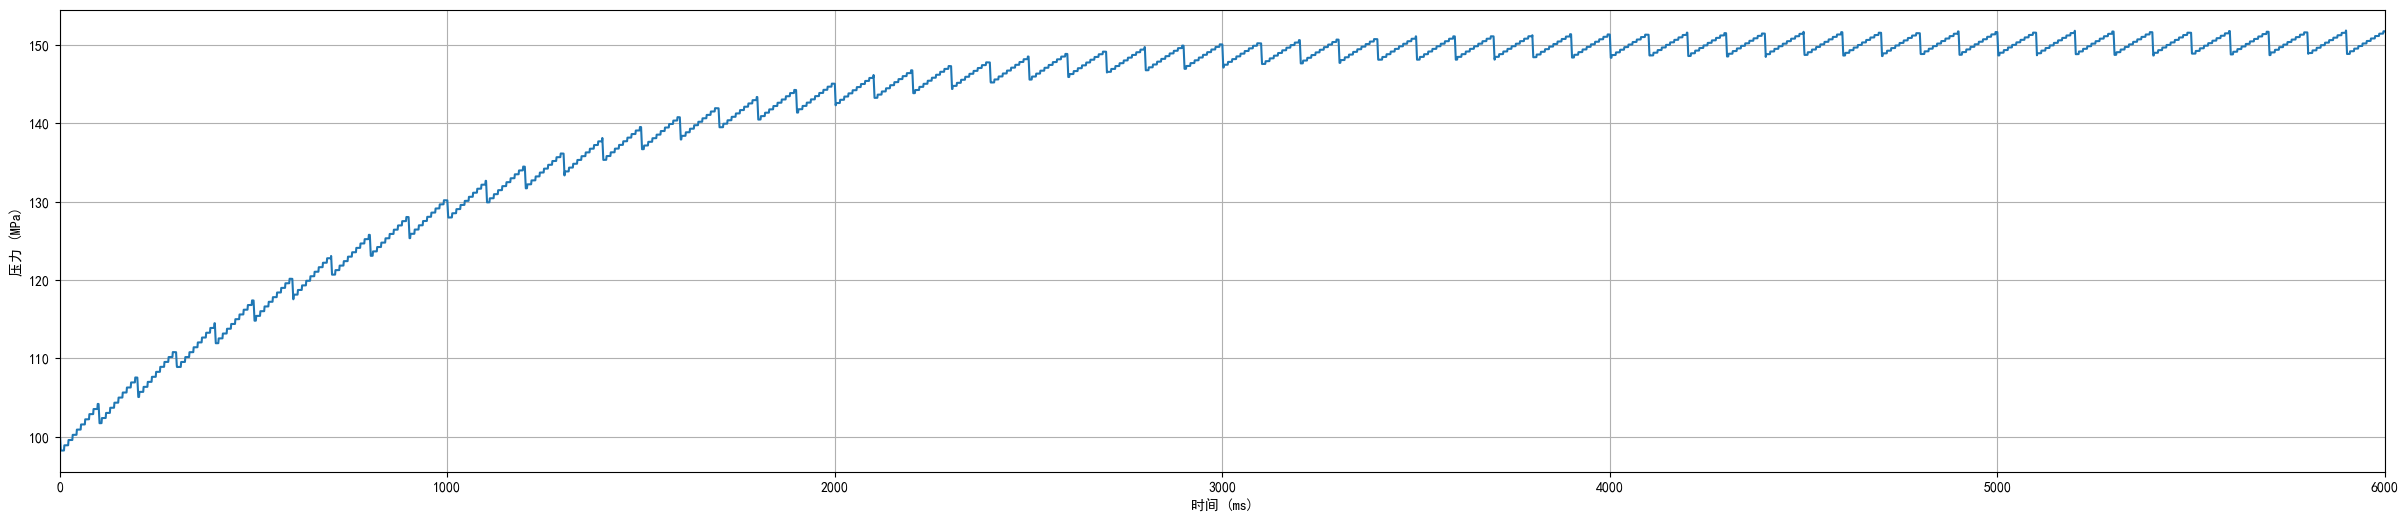

In [112]:
plt.figure(figsize=(30, 6))
plt.plot(time_grid_valid[0:600000], P[0:600000])
#plt.plot(time_grid_valid, P)
plt.xlabel('时间 (ms)')
plt.ylabel('压力 (MPa)')
plt.xlim(0, 6000)
plt.grid(True)
plt.show()


In [69]:
p2s = P

In [101]:
p5s = simulate_pressure_valid(0.75247370248716)

In [102]:
p10s = simulate_pressure_valid(0.75232963685490)

In [113]:
p4s = simulate_pressure_valid(0.76402151850178)

In [133]:
p2s2 = simulate_pressure_valid(0.92892947716501)

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(time_grid_valid, p2s2, label='t_target = 2s,  t_a  = 0.928929', color='m', linestyle='-', alpha=0.5)
plt.plot(time_grid_valid, p2s, label='t_target = 2s,  t_a1 = 0.928929, t_a2 = 0.751608', color='y', linestyle='-', alpha=0.7)
plt.plot(time_grid_valid, p4s, label='t_target 边界状态', color='r', linestyle='-', alpha=0.9)  
plt.plot(time_grid_valid, p5s, label='t_target = 5s,  t_a  = 0.751722', color='b', linestyle='-', alpha=0.5)
plt.plot(time_grid_valid, p10s, label='t_target = 10s, t_a  = 0.752330', color='g', linestyle='-', alpha=0.5)   


plt.xlabel('时间 (ms)')
plt.ylabel('压力 (MPa)')
plt.xlim(0, 10000)
# plt.xlim(1950, 3900)
# plt.ylim(140, 155)

plt.legend(fontsize='large')  # 显示图例
plt.grid(True)
plt.show()
#plt.savefig('sin_plot.pdf', format='pdf', bbox_inches='tight', dpi=300)

####